# Test 1: SWF estimation using formula

As a baseline, we'll calculate Surface Water Fracture following the physical formula:

$$
f_w = \frac{\epsilon_h^{obs} - \epsilon_{hl}^{ref}}{\epsilon_{hw}^{ref} - \epsilon_{hl}^{ref}}
$$

The main objective of this project is to improve on these results.

https://nsidc.org/sites/default/files/documents/technical-reference/readme_lpdr_nsidc-0451-v31.pdf

### Library importing

In [9]:
import os
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import cftime

from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

from CIMR.SurfaceWaterFraction_ATBD_main.algorithm.processing import colormaps
from CIMR.SurfaceWaterFraction_ATBD_main.algorithm.processing.validation_data_processing import load_lut, unravel_freqpol, atmospheric_corrections

import os
from datetime import datetime
import zipfile
import xarray as xr  
import rasterio
import numpy as np
import io

### Data loading

In [35]:
atbd_root_dir = Path(os.getcwd()).resolve().parent
sys.path.append(str(atbd_root_dir))

# Open data
data_dir = os.path.join(os.getcwd(), '..', 'data')

# Load the LUT with reference land emissivities
lut_h_path = 'CIMR/SurfaceWaterFraction_ATBD-main/data/lut_de_lannoy_K_h.csv'
lut_v_path = 'CIMR/SurfaceWaterFraction_ATBD-main/data/lut_de_lannoy_K_v.csv'

# Load the Windsat data
local_tds = '../data/Windsat/RSS_WINDSAT_DAILY_TBTOA_MAPS_2018_12_31.nc'

tds = xr.open_dataset(local_tds, decode_times=False)

# Define a time decoder using cftime
time_coder = xr.coding.variables.CFDatetimeCoder(use_cftime=True)

# Decode CF-compliant variables (including 'time')
decoded = xr.decode_cf(tds, decode_times=time_coder)

# Replace the time variable in your dataset
tds['time'] = decoded['time']

tds 

<xarray.Dataset> Size: 1GB
Dimensions:         (longitude_grid: 1440, latitude_grid: 720, swath_sector: 2,
                     look_direction: 2, frequency_band: 5, polarization: 4,
                     polarization_dual: 2)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band, polarization,
                                polarization_dual
Data variables: (12/34)
    longitude       (longitude_grid) float32 6kB ...
    latitude        (latitude_grid) float32 3kB ...
    node            (swath_sector) int32 8B ...
    look            (look_direction) int32 8B ...
    frequency_vpol  (frequency_band) float32 20B ...
    frequency_hpol  (frequency_band) float32 20B ...
    ...              ...
    colcld_WSAT     (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_IMERG      (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    rain_WSAT       (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    tran            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbup            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbdw            (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

### Step 1 — Identify necessary variables

We start off by extracting the polarization of the necessary variables to compute the SWF.

In [36]:
# Slice polarization
tbtoa_h = tds['tbtoa'].isel({'polarization': 1})
tbup_h  = tds['tbup'].isel({'polarization_dual': 1})
tbdw_h  = tds['tbdw'].isel({'polarization_dual': 1})
tran_h  = tds['tran'].isel({'polarization_dual': 1})

# Store into tds
tds['tbtoa_h'] = tbtoa_h
tds['tbup_h']  = tbup_h
tds['tbdw_h']  = tbdw_h
tds['tran_h']  = tran_h

### Step 2 — Compute BOA brightness temperature

Following the formula

$$
TB_p^{\text{BOA}} =
T_{\text{skin}}
\left[
\frac{
TB_p^{\text{TOA}} \, \Gamma^{-1}
-
\left(1 + \Gamma^{-1}\right) TB_{\text{atm}}^{up}
}{
T_{\text{skin}} - TB_{\text{atm}}^{down}
}
\right]
$$

we compute $BOA$, a necessary step when calculating SWF.

In [37]:
# Broadcast arrays to consistent shape using xarray
tbtoa_h, tbup_h, tbdw_h, tran_h, t_skin = xr.broadcast(tds.tbtoa_h, tds.tbup_h, tds.tbdw_h, tds.tran_h, tds.surtep_ERA5)

# Compute the formula for tb_boa
tb_boa = t_skin * (tbtoa_h/tran_h - (1.0 + 1.0/tran_h) * tbup_h) / (t_skin - tbdw_h)

# Store into tds
tds['tb_boa_h'] = tb_boa

### Step 3 — Compute observed emissivity

Another value we will need is the observed emissivity.

$$
\epsilon_{obs} = \frac{TB_{BOA}}{T_{skin}}
$$

In [38]:
# Compute the formula for eps_obs
tds['eps_obs'] = (tds.tb_boa_h / tds.surtep_ERA5).astype(float)

### Step 5 — estimate σ_ε (emissivity uncertainty) from σ_TB and σ_Tskin (Eq.6.15)

In [39]:
# If you have instrument uncertainty fields in tds, use them:
# tds['sigma_tb'] and tds['sigma_tskin'] (optional). Otherwise use defaults:
sigma_tb = tds.get('sigma_tb', 0.5)       # default 0.5 K, change if you have better number
sigma_tskin = tds.get('sigma_tskin', 1.0) # default 1.0 K

# make sure sigma_tb and sigma_tskin are DataArrays
sigma_tb_da = xr.DataArray(sigma_tb)
sigma_tskin_da = xr.DataArray(sigma_tskin)

# broadcast to match shapes
tb_sel, t_skin_sel, sigma_tb_sel, sigma_tskin_sel = xr.broadcast(
    tds.tbtoa_h, tds.surtep_ERA5, sigma_tb_da, sigma_tskin_da
)

term1 = (1.0 / t_skin_sel)**2 * (sigma_tb_sel**2)
term2 = (tds.tbtoa_h / (t_skin_sel**2))**2 * (sigma_tskin_sel**2)
sigma_eps = np.sqrt(term1 + term2)

tds['sigma_eps'] = sigma_eps

### Step 6 — prepare reference emissivities (LUT placeholders or per-pixel arrays)

In [40]:
# IMPORTANT: replace placeholders below with your LUT lookup (SM & VOD -> eps_land_ref & sigma_hl).
# For now we create simple placeholders (must be replaced for accurate results):

# Example placeholders (scalars)
eps_land_ref_val = 0.92   # placeholder: typical land value — replace with LUT result
eps_water_ref_val = 0.50  # placeholder: example water emissivity — replace with LUT result
sigma_hl_val = 0.02       # placeholder uncertainty for land ref
sigma_hw_val = 0.01       # placeholder uncertainty for water ref

# Broadcast to data shape
eps_land_ref = xr.broadcast(xr.DataArray(eps_land_ref_val), tds.eps_obs)[0]
eps_water_ref = xr.broadcast(xr.DataArray(eps_water_ref_val), tds.eps_obs)[0]
sigma_hl = xr.broadcast(xr.DataArray(sigma_hl_val), tds.eps_obs)[0]
sigma_hw = xr.broadcast(xr.DataArray(sigma_hw_val), tds.eps_obs)[0]

tds['eps_land_ref'] = eps_land_ref
tds['eps_water_ref'] = eps_water_ref
tds['sigma_hl'] = sigma_hl
tds['sigma_hw'] = sigma_hw

print("Reference emissivities set as placeholders. Replace with LUT lookup for science-grade results.")

Reference emissivities set as placeholders. Replace with LUT lookup for science-grade results.


### Step 7 — compute SWF (difference ratio) and clip to $[0,1]$

In [41]:
eps_delta = tds.eps_water_ref - tds.eps_land_ref
swf_raw = (tds.eps_obs - tds.eps_land_ref) / eps_delta
swf = swf_raw.clip(0.0, 1.0)

tds['eps_delta'] = eps_delta
tds['swf_raw'] = swf_raw
tds['swf'] = swf

### Step 8 — propagate SWF uncertainty (Eq.6.12)

In [42]:
delta = tds.eps_water_ref - tds.eps_land_ref

a = (1.0 / delta)**2 * (tds.sigma_eps**2)
b = ((tds.eps_obs - tds.eps_water_ref)**2 / delta**4) * (tds.sigma_hl**2)
c = ((tds.eps_land_ref - tds.eps_obs)**2 / delta**4) * (tds.sigma_hw**2)

sigma_swf2 = a + b + c
# guard against tiny negative rounding errors
sigma_swf2 = xr.where(sigma_swf2 < 0, 0.0, sigma_swf2)
sigma_swf = np.sqrt(sigma_swf2)

tds['swf_uncert'] = sigma_swf

### Step 9 — basic status flags (incremental bits; extend later)

In [43]:
# define bits:
# bit 0 (1): quality_flag nonzero (if exists)
# bit 1 (2): unstable denominator (eps_delta tiny)
# bit 2 (4): fland_06 > 0.5 (land-dominant)
# bit 3 (8): tb_boa or eps_obs NaN (invalid)

status = xr.zeros_like(tds.swf, dtype=np.int16)

# bit 0
qf = tds.quality_flag
# broadcast qf to swf shape
qf = xr.broadcast(qf, tds.swf)[0]
status = status | xr.where(qf != 0, 1, 0).astype(np.int16)

# bit 1
status = status | xr.where(np.abs(tds.eps_delta) <= 1e-6, 2, 0).astype(np.int16)

# bit 2
fl06 = xr.broadcast(tds.fland_06, tds.swf)[0]
status = status | xr.where(fl06 > 0.5, 4, 0).astype(np.int16)

# bit 3
status = status | xr.where(tds.eps_obs.isnull(), 8, 0).astype(np.int16)

tds['status_flag'] = status

### Step 10 — quick diagnostics (run to inspect results)

In [44]:
print("SWF stats (valid values):")
valid = ~np.isnan(tds.swf)
print("count valid:", int(valid.sum().values))
print("swf mean:", float(tds.swf.where(valid).mean()))
print("swf std:", float(tds.swf.where(valid).std()))

# show a small sample (first lat/lon slice) — adjust dims as needed
print(tds[['eps_obs','swf','swf_uncert','status_flag']].isel({list(tds.dims)[0]: 0, list(tds.dims)[1]: 0}))

SWF stats (valid values):
count valid: 6335686
swf mean: 0.6165722422036906
swf std: 0.4112593484281806
<xarray.Dataset> Size: 520B
Dimensions:      (frequency_band: 5, look_direction: 2, swath_sector: 2)
Dimensions without coordinates: frequency_band, look_direction, swath_sector
Data variables:
    eps_obs      (frequency_band, look_direction, swath_sector) float64 160B ...
    swf          (frequency_band, look_direction, swath_sector) float64 160B ...
    swf_uncert   (frequency_band, look_direction, swath_sector) float64 160B ...
    status_flag  (frequency_band, look_direction, swath_sector) int16 40B 9 ....
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledg

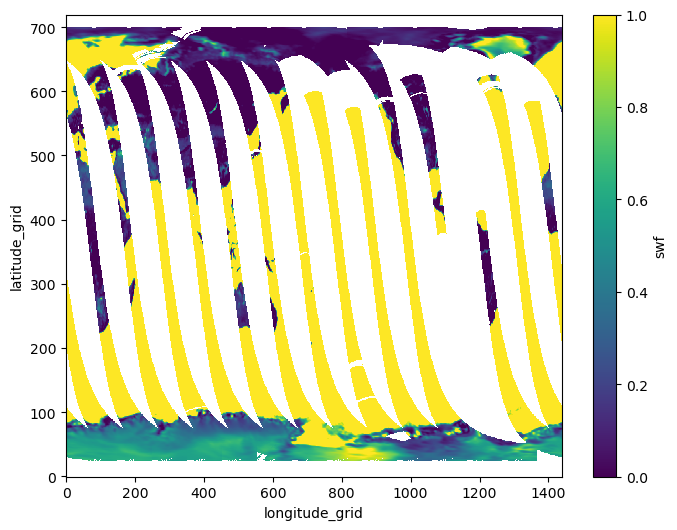

In [45]:
tds.swf.isel(frequency_band=0, look_direction=0, swath_sector=0).plot(size=6)

In [46]:
tds

<xarray.Dataset> Size: 3GB
Dimensions:         (longitude_grid: 1440, latitude_grid: 720, swath_sector: 2,
                     look_direction: 2, frequency_band: 5, polarization: 4,
                     polarization_dual: 2)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band, polarization,
                                polarization_dual
Data variables: (12/50)
    longitude       (longitude_grid) float32 6kB ...
    latitude        (latitude_grid) float32 3kB ...
    node            (swath_sector) int32 8B ...
    look            (look_direction) int32 8B ...
    frequency_vpol  (frequency_band) float32 20B ...
    frequency_hpol  (frequency_band) float32 20B ...
    ...              ...
    sigma_hw        (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float64 166MB ...
    eps_delta       (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float64 166MB ...
    swf_raw         (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float64 166MB ...
    swf             (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float64 166MB ...
    swf_uncert      (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float64 166MB ...
    status_flag     (frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) int16 41MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

## Cálculo acelerado

In [19]:
tds = atmospheric_corrections(tds)
tds

<xarray.Dataset> Size: 3GB
Dimensions:          (longitude_grid: 1440, latitude_grid: 720,
                      swath_sector: 2, look_direction: 2, frequency_band: 5,
                      polarization: 4, polarization_dual: 2)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band, polarization,
                                polarization_dual
Data variables: (12/36)
    longitude        (longitude_grid) float32 6kB ...
    latitude         (latitude_grid) float32 3kB ...
    node             (swath_sector) int32 8B ...
    look             (look_direction) int32 8B ...
    frequency_vpol   (frequency_band) float32 20B ...
    frequency_hpol   (frequency_band) float32 20B ...
    ...               ...
    rain_WSAT        (latitude_grid, longitude_grid, swath_sector) float32 8MB ...
    tran             (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbup             (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbdw             (polarization_dual, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector) float32 166MB ...
    tbboa_1st_order  (polarization, frequency_band, latitude_grid, longitude_grid, look_direction, swath_sector, polarization_dual) float32 664MB ...
    tbboa_de_lannoy  (latitude_grid, longitude_grid, swath_sector, polarization, frequency_band, look_direction, polarization_dual) float32 664MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

In [20]:
# unravel tbtoa layer into frequency and polarization arrays
tds = unravel_freqpol(tds, dvars=[
    "tbtoa", "tbboa_de_lannoy"
])

# Drop the multy dimentional dvars that we dont need anymore
tds = tds.drop_vars(["tbtoa", "tbboa_de_lannoy"])
tds

<xarray.Dataset> Size: 2GB
Dimensions:             (longitude_grid: 1440, latitude_grid: 720,
                         swath_sector: 2, look_direction: 2, frequency_band: 5,
                         polarization_dual: 2, polarization: 4)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band,
                                polarization_dual, polarization
Data variables: (12/42)
    longitude           (longitude_grid) float32 6kB ...
    latitude            (latitude_grid) float32 3kB ...
    node                (swath_sector) int32 8B ...
    look                (look_direction) int32 8B ...
    frequency_vpol      (frequency_band) float32 20B ...
    frequency_hpol      (frequency_band) float32 20B ...
    ...                  ...
    tbtoa37V            (latitude_grid, longitude_grid, look_direction, swath_sector) float32 17MB ...
    tbtoa37H            (latitude_grid, longitude_grid, look_direction, swath_sector) float32 17MB ...
    tbboa_de_lannoy19V  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    tbboa_de_lannoy19H  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    tbboa_de_lannoy37V  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    tbboa_de_lannoy37H  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

In [21]:
# Get emissivity from TDS, Which has ERA5 skin temperature
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        tds[f"emiss{freq}{pol}_de_lannoy"] = tds[f"tbboa_de_lannoy{freq}{pol}"] / tds["surtep_ERA5"]

tds

<xarray.Dataset> Size: 2GB
Dimensions:             (longitude_grid: 1440, latitude_grid: 720,
                         swath_sector: 2, look_direction: 2, frequency_band: 5,
                         polarization_dual: 2, polarization: 4)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band,
                                polarization_dual, polarization
Data variables: (12/46)
    longitude           (longitude_grid) float32 6kB ...
    latitude            (latitude_grid) float32 3kB ...
    node                (swath_sector) int32 8B ...
    look                (look_direction) int32 8B ...
    frequency_vpol      (frequency_band) float32 20B ...
    frequency_hpol      (frequency_band) float32 20B ...
    ...                  ...
    tbboa_de_lannoy37V  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    tbboa_de_lannoy37H  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss19H_de_lannoy  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss19V_de_lannoy  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss37H_de_lannoy  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss37V_de_lannoy  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

In [24]:
# Example placeholders (scalars)
eps_land_ref_val = 0.92   # placeholder: typical land value — replace with LUT result
# Broadcast to data shape
ref_land_emis_de_lannoy_K = xr.broadcast(xr.DataArray(eps_land_ref_val), tds.emiss19H_de_lannoy)[0]

tds['ref_land_emis_de_lannoy_K'] = ref_land_emis_de_lannoy_K

In [25]:
# SWF computation
ref_water_emiss_h = 0.288760

tds["SWF_DR"] = (tds.emiss19H_de_lannoy - tds.ref_land_emis_de_lannoy_K) / (ref_water_emiss_h - tds.ref_land_emis_de_lannoy_K)
tds

<xarray.Dataset> Size: 2GB
Dimensions:                                        (longitude_grid: 1440,
                                                    latitude_grid: 720,
                                                    swath_sector: 2,
                                                    look_direction: 2,
                                                    frequency_band: 5,
                                                    polarization_dual: 2,
                                                    polarization: 4)
Dimensions without coordinates: longitude_grid, latitude_grid, swath_sector,
                                look_direction, frequency_band,
                                polarization_dual, polarization
Data variables: (12/49)
    longitude                                      (longitude_grid) float32 6kB ...
    latitude                                       (latitude_grid) float32 3kB ...
    node                                           (swath_sector) int32 8B ...
    look                                           (look_direction) int32 8B ...
    frequency_vpol                                 (frequency_band) float32 20B ...
    frequency_hpol                                 (frequency_band) float32 20B ...
    ...                                             ...
    emiss19V_de_lannoy                             (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss37H_de_lannoy                             (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss37V_de_lannoy                             (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float32 33MB ...
    emiss19ref_land_emis_de_lannoy_K_hH_de_lannoy  (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float64 66MB ...
    ref_land_emis_de_lannoy_K                      (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float64 66MB ...
    SWF_DR                                         (latitude_grid, longitude_grid, swath_sector, look_direction, polarization_dual) float64 66MB ...
Attributes: (12/71)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_NOAA_OI_SST:        NOAA OI SST V2 High Resolution Da...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, GL...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...

In [33]:
tds.SWF_DR.isel(frequency_band=0, look_direction=0, swath_sector=0).plot(size=6)

ValueError: Dimensions {'frequency_band'} do not exist. Expected one or more of ('latitude_grid', 'longitude_grid', 'swath_sector', 'look_direction', 'polarization_dual')

c:\Users\marce\anaconda3\envs\tfm\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


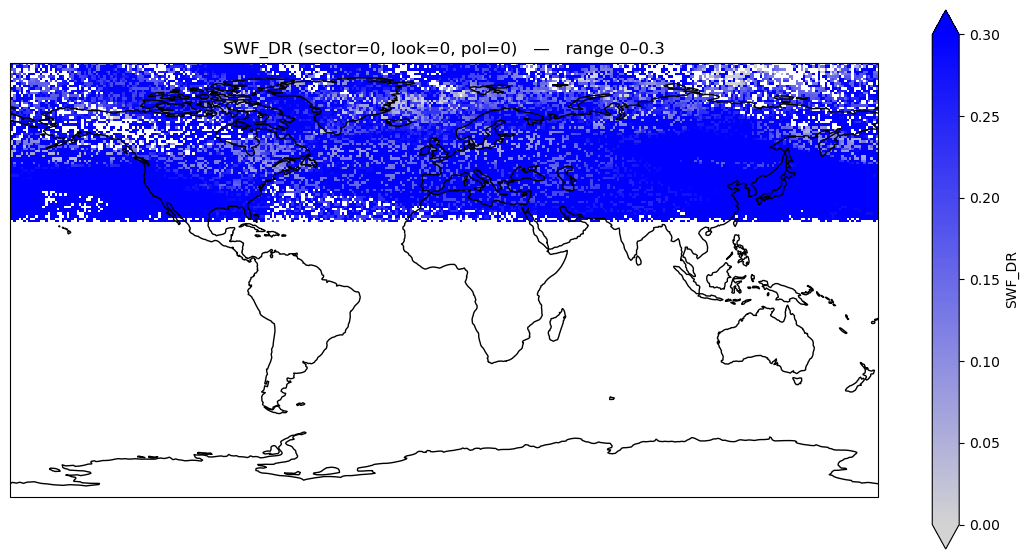

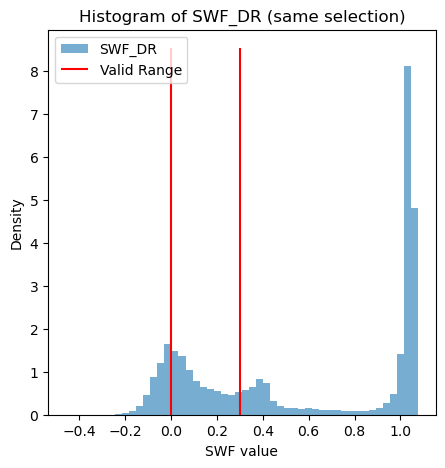

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs

# --- Custom colormap ---
colors = ["#d3d3d3", "blue"]
cmap_ = LinearSegmentedColormap.from_list("LightGrayToBlue", colors)

# ============================================================
# 1. REDUCE TO 2D FOR MAPPING
#    (choose specific swath_sector, look_direction, polarization)
# ============================================================

swf2d = tds.SWF_DR.isel(
    swath_sector=0,
    look_direction=0,
    polarization_dual=0
)

# ============================================================
# 2. MAP PLOT
# ============================================================

fig, ax = plt.subplots(
    1, 1, figsize=(14, 7),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)}
)

swf2d.plot.imshow(
    ax=ax,
    vmin=0,
    vmax=0.3,
    cmap=cmap_
)

ax.coastlines("110m")
ax.set_title("SWF_DR (sector=0, look=0, pol=0)   —   range 0–0.3")


# ============================================================
# 3. HISTOGRAM
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

values = swf2d.values.flatten()
values = values[~np.isnan(values)]

ax.hist(values, bins=50, density=True, alpha=0.6, label="SWF_DR")

ax.vlines(x=[0, 0.3], ymin=0, ymax=ax.get_ylim()[1], colors="red", label="Valid Range")
ax.legend()
ax.set_title("Histogram of SWF_DR (same selection)")
ax.set_xlabel("SWF value")
ax.set_ylabel("Density")

plt.show()


In [30]:
print(tds.SWF_DR)
print("DIMS:", tds.SWF_DR.dims)
print("SHAPE:", tds.SWF_DR.shape)
print("COORDS:", list(tds.SWF_DR.coords))


<xarray.DataArray 'SWF_DR' (latitude_grid: 720, longitude_grid: 1440,
                            swath_sector: 2, look_direction: 2,
                            polarization_dual: 2)> Size: 66MB
array([[[[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]],


        [[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]],


        [[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]],

...

        [[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]],


        [[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]],


        [[[nan, nan],
          [nan, nan]],

         [[nan, nan],
          [nan, nan]]]]], shape=(720, 1440, 2, 2, 2))
Dimensions without coordinates: latitude_grid, longitude_grid, swath_sector,
                                look_direction, polarization_dual
DIMS: ('latitude_grid', 'longitude_grid', 'swath_sector', 'look_d

## 20 de Marzo de 2017

In [3]:
LPDR_path = '../data/LPDR/2017h5/AMSRU_Mland_2017079A.h5'
KU_path = '../data/18ghz/GW1AM2_20170320_01D_EQMA_L3SGT18LA2220220_corrected.h5'
KA_path = '../data/36ghz/GW1AM2_20170320_01D_EQMA_L3SGT36LA2220220_corrected.h5'

lpdr_ds = xr.open_dataset(LPDR_path, engine='netcdf4')
ku_ds = xr.open_dataset(KU_path, engine='netcdf4')
ka_ds = xr.open_dataset(KA_path, engine='netcdf4')

In [11]:
lpdr_ds

<xarray.Dataset> Size: 23MB
Dimensions:    (band: 7, lat: 586, lon: 1383)
Coordinates:
  * band       (band) int64 56B 0 1 2 3 4 5 6
  * lat        (lat) float64 5kB 7.345e+06 7.32e+06 ... -7.295e+06 -7.32e+06
  * lon        (lon) float64 11kB -1.733e+07 -1.731e+07 ... 1.728e+07 1.731e+07
Data variables:
    band_data  (band, lat, lon) float32 23MB -999.0 -999.0 ... -999.0 -999.0

In [7]:
def process_ldpr_dataset(lpdr_file):
    lpdr_ds = xr.open_dataset(lpdr_file, engine='netcdf4')
    
    df = lpdr_ds.to_dataframe()
    df = df.reset_index()
    
    df_pivot = df.pivot(index=['lat', 'lon', 'landmask'], columns='band', values='band_data')  
    
    df_pivot.columns = ['fwns', 'fw', 'air temperature', 'PWV', 'VOD', 'vsm', 'VPD', '7', '8']
    df_pivot = df_pivot.drop(columns=['7', '8'])
    df_pivot.dropna(inplace=True)
    
    ds = df_pivot.reset_index().set_index(['lat', 'lon']).to_xarray()
    
    return ds

In [10]:
process_ldpr_dataset(LPDR_path)

KeyError: 'landmask'

In [ ]:
ku_ds

NameError: name 'ku_ds' is not defined

In [6]:
ka_ds

<xarray.Dataset> Size: 10MB
Dimensions:                     (lon: 1388, lat: 584)
Coordinates:
  * lon                         (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
  * lat                         (lat) float32 2kB -83.52 -81.98 ... 81.98 83.52
Data variables:
    Brightness Temperature (H)  (lat, lon) float32 3MB ...
    Brightness Temperature (V)  (lat, lon) float32 3MB ...
    Time Information            (lat, lon) float32 3MB ...
Attributes: (12/28)
    CDI:                       Climate Data Interface version 1.9.9 (https://...
    Conventions:               CF-1.6
    ProductName:               AMSR2-L3
    GeophysicalName:           Brightness Temperature (36GHz)
    MeanType:                  DayMean
    Projection:                EQR
    ...                        ...
    OrbitDirection:            Ascending
    PlatformShortName:         GCOM-W1
    SensorShortName:           AMSR2
    ECSDataModel:              B.0
    history:                   Tue Apr 27 13:17:30 2021: cdo remapbil,/media/...
    CDO:                       Climate Data Operators version 1.9.9 (https://...

In [5]:
# SWF computation
ref_water_emiss_h = 0.288760

tds["SWF_DR"] = (tds.ref_land_emis_de_lannoy_K_h - tds.emiss19H_de_lannoy) / (tds.ref_land_emis_de_lannoy_K_v - ref_water_emiss_h)
tds

NameError: name 'tds' is not defined